In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [ ]:
apps = pd.read_csv('/content/googleplaystore.csv')
reviews = pd.read_csv('/content/googleplaystore_user_reviews.csv')

print("Apps:", apps.shape)
print("Reviews:", reviews.shape)

Apps: (10841, 13)
Reviews: (64295, 5)


In [ ]:
apps = apps.dropna(subset=['App', 'Category', 'Reviews'])
apps['Reviews'] = pd.to_numeric(apps['Reviews'], errors='coerce')
apps = apps.drop_duplicates('App')

print("Clean Apps:", len(apps))

Clean Apps: 9660


In [ ]:
reviews = reviews.dropna(subset=['Translated_Review'])

reviews['Translated_Review'] = reviews['Translated_Review'].str.strip()

reviews = reviews[reviews['Translated_Review'].str.len() >= 10]

reviews = reviews.drop_duplicates(['App', 'Translated_Review'])

print("Clean Reviews:", len(reviews))

Clean Reviews: 27307


In [ ]:
health = apps[apps['Category'] == 'HEALTH_AND_FITNESS']

health = health[health['Reviews'] >= 100]

print("Health & Fitness Apps:", len(health))

Health & Fitness Apps: 201


In [ ]:
top30 = health.sort_values('Reviews', ascending=False).head(30)

display(top30[['App', 'Reviews', 'Rating']])

,App,Reviews,Rating
1360,Period Tracker - Period Calendar Ovulation Tra...,4559407.0,4.8
1286,Calorie Counter - MyFitnessPal,1873516.0,4.6
1277,Runtastic Running App & Mile Tracker,827597.0,4.5
1281,Nike+ Run Club,708674.0,4.4
1361,Period Tracker Clue: Period and Ovulation Tracker,570242.0,4.8
1289,Endomondo - Running & Walking,559186.0,4.5
1265,"Pedometer, Step Counter & Weight Loss Tracker App",548021.0,4.6
1369,Water Drink Reminder,524299.0,4.6
1292,Runkeeper - GPS Track Run Walk,501144.0,4.5
5596,Samsung Health,480208.0,4.3


In [ ]:
final = reviews[reviews['App'].isin(top30['App'])].copy()

print("Matching Apps:", final['App'].nunique())
print("Matching Reviews:", len(final))

Matching Apps: 8
Matching Reviews: 272


In [ ]:
final['Review_Length'] = final['Translated_Review'].str.len()

print("Average Review Length:",
      round(final['Review_Length'].mean(), 2))

Average Review Length: 147.33


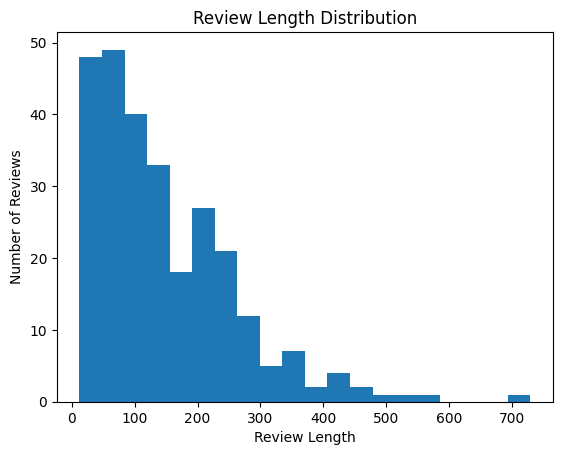

In [ ]:
plt.hist(final['Review_Length'], bins=20)

plt.title('Review Length Distribution')
plt.xlabel('Review Length')
plt.ylabel('Number of Reviews')

plt.show()

In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.6 MB/s eta 0:00:00


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

In [ ]:
final['VADER_Score'] = final['Translated_Review'].apply(
    lambda x: analyzer.polarity_scores(x)['compound']
)

In [ ]:
def sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

final['VADER_Sentiment'] = final['VADER_Score'].apply(sentiment)

print(final['VADER_Sentiment'].value_counts())

VADER_Sentiment
Positive    192
Negative     50
Neutral      30
Name: count, dtype: int64


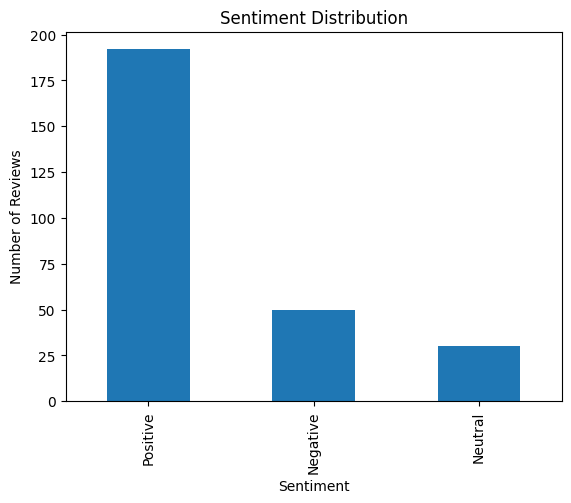

In [ ]:
final['VADER_Sentiment'].value_counts().plot(kind='bar')

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()

In [ ]:
app_sentiment = pd.crosstab(
    final['App'],
    final['VADER_Sentiment']
)

display(app_sentiment)

VADER_Sentiment,Negative,Neutral,Positive
App,,,
30 Day Fitness Challenge - Workout at Home,3,1,26
7 Minute Workout,1,0,10
Calorie Counter - MyFitnessPal,14,18,63
"Fabulous: Motivate Me! Meditate, Relax, Sleep",5,0,24
Fitbit,3,0,3
Garmin Connect™,12,4,24
Google Fit - Fitness Tracking,12,7,16
Home Workout - No Equipment,0,0,26


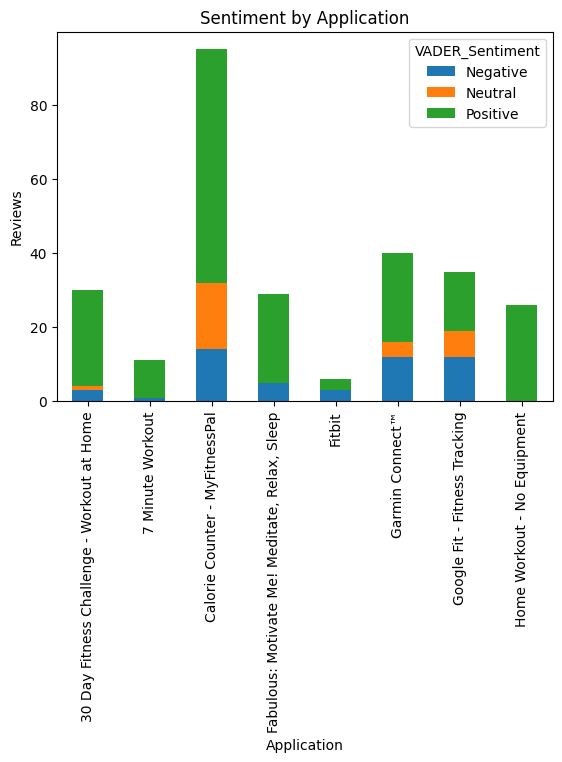

In [ ]:
app_sentiment.plot(kind='bar', stacked=True)

plt.title('Sentiment by Application')
plt.xlabel('Application')
plt.ylabel('Reviews')
plt.xticks(rotation=90)

plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=20
)

matrix = tfidf.fit_transform(final['Translated_Review'])

In [ ]:
features = tfidf.get_feature_names_out()

scores = matrix.mean(axis=0).A1

feature_table = pd.DataFrame({
    'Feature': features,
    'Score': scores
})

feature_table = feature_table.sort_values(
    'Score', ascending=False
)

display(feature_table)

,Feature,Score
0,app,0.126830
9,like,0.101763
8,great,0.097328
7,good,0.089950
3,day,0.070085
12,really,0.063566
16,way,0.061107
4,easy,0.059073
10,love,0.054235
17,work,0.052156


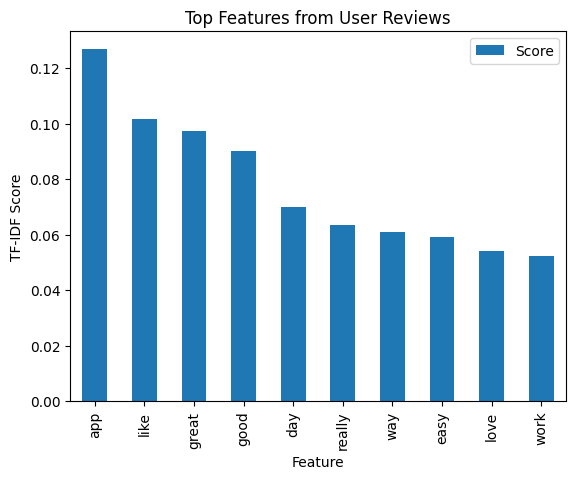

In [ ]:
feature_table.head(10).plot(
    x='Feature',
    y='Score',
    kind='bar'
)

plt.title('Top Features from User Reviews')
plt.xlabel('Feature')
plt.ylabel('TF-IDF Score')

plt.show()

In [ ]:
rice = feature_table.head(10).copy()

rice['Reach'] = 1
rice['Impact'] = 2
rice['Confidence'] = 0.8
rice['Effort'] = 1

In [ ]:
for word in rice['Feature']:
    rice.loc[rice['Feature'] == word, 'Reach'] = final[
        'Translated_Review'
    ].str.lower().str.contains(word, regex=False).sum()

In [ ]:
rice['RICE_Score'] = (
    rice['Reach'] *
    rice['Impact'] *
    rice['Confidence'] /
    rice['Effort']
)

rice = rice.sort_values('RICE_Score', ascending=False)

display(rice)

,Feature,Score,Reach,Impact,Confidence,Effort,RICE_Score
0,app,0.126830,85,2,0.8,1,136.0
17,work,0.052156,71,2,0.8,1,113.6
9,like,0.101763,55,2,0.8,1,88.0
8,great,0.097328,55,2,0.8,1,88.0
3,day,0.070085,55,2,0.8,1,88.0
7,good,0.089950,44,2,0.8,1,70.4
16,way,0.061107,41,2,0.8,1,65.6
10,love,0.054235,31,2,0.8,1,49.6
12,really,0.063566,30,2,0.8,1,48.0
4,easy,0.059073,29,2,0.8,1,46.4


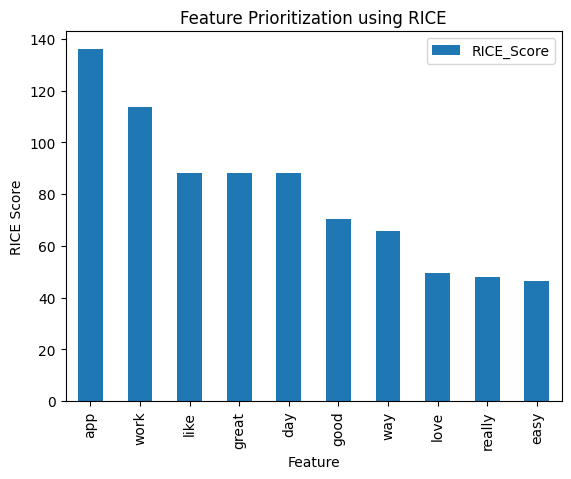

In [ ]:
rice.plot(
    x='Feature',
    y='RICE_Score',
    kind='bar'
)

plt.title('Feature Prioritization using RICE')
plt.xlabel('Feature')
plt.ylabel('RICE Score')

plt.show()

In [ ]:
print("Total Reviews:", len(final))
print("Total Apps:", final['App'].nunique())
print("Missing Reviews:", final['Translated_Review'].isna().sum())
print("Missing VADER Scores:", final['VADER_Score'].isna().sum())
print("Missing Sentiment:", final['VADER_Sentiment'].isna().sum())

Total Reviews: 272
Total Apps: 8
Missing Reviews: 0
Missing VADER Scores: 0
Missing Sentiment: 0


In [ ]:
final.to_csv('final_review_analysis.csv', index=False)
rice.to_csv('feature_rice_prioritization.csv', index=False)

print("Results saved successfully")

Results saved successfully
